In [1]:
import pandas as pd
import numpy as np
import sklearn 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

In [53]:
df = pd.read_csv("ToyotaCorolla.csv")

In [54]:
df.head()

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23,46986,Diesel,90,1,0,2000,3,1165
1,13750,23,72937,Diesel,90,1,0,2000,3,1165
2,13950,24,41711,Diesel,90,1,0,2000,3,1165
3,14950,26,48000,Diesel,90,0,0,2000,3,1165
4,13750,30,38500,Diesel,90,0,0,2000,3,1170


In [55]:
df.describe()

,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.674791,0.055710,1566.827994,4.033426,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.468616,0.229441,187.182436,0.952677,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,0.000000,1300.000000,2.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,0.000000,1400.000000,3.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,1.000000,0.000000,1600.000000,4.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,1.000000,0.000000,1600.000000,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,1.000000,2000.000000,5.000000,1615.00000


In [41]:
print(df.info(), "\n")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1436 non-null   int64
 1   Age        1436 non-null   int64
 2   KM         1436 non-null   int64
 3   FuelType   1436 non-null   str  
 4   HP         1436 non-null   int64
 5   MetColor   1436 non-null   int64
 6   Automatic  1436 non-null   int64
 7   CC         1436 non-null   int64
 8   Doors      1436 non-null   int64
 9   Weight     1436 non-null   int64
dtypes: int64(9), str(1)
memory usage: 112.3 KB
None 

Price        0
Age          0
KM           0
FuelType     0
HP           0
MetColor     0
Automatic    0
CC           0
Doors        0
Weight       0
dtype: int64


In [56]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

Price: [13500 13750 13950 14950 12950 16900 18600 21500 20950 19950 19600 22500
 22000 22750 17950 16750 16950 15950 16250 17495 15750 15500 14750 19000
 15800 21950 20500 13250 15250 18950 15999 16500 18750 22250 12995 18450
 16895 14900 17250 15450 16650 17450 16450 18900 18990 18500 19450 18800
 32500 31000 31275 24950 22950 24990 17900 19250 16350 21750 15850 23000
 19900 23950 24500 17200 19500 16868 19750 20750 17650 17795 18245 23750
 18700 21125  6950  9500 11950  7750  4350  4750 11750 11900  9950 11495
 11250 10500 10450 11500 12500 10950 11450 11790 12450 11690 12750 11925
 12900 11650 10850  9940 13450 12495 12000 11480 14990 12850 11700 11895
 13875 12295 13995  9900 11990 10750 11695 11000 12400 12200 12695 14350
 10250  6500  6400  7000  8900  8500  8950  9250  9450  8250  4450  9000
  5150  7900 10900  9750 11290 10895 10995  9850  8695 10990  8750  9930
  9799  9700  9990  9475 10000 10495  9400  9650  9550 13000 11710  9980
 12250 11930 10800 10600  7500  5950  6900  

In [57]:
df.groupby(["FuelType"]).count()

,Price,Age,KM,HP,MetColor,Automatic,CC,Doors,Weight
FuelType,,,,,,,,,
CNG,17,17,17,17,17,17,17,17,17
Diesel,155,155,155,155,155,155,155,155,155
Petrol,1264,1264,1264,1264,1264,1264,1264,1264,1264


In [58]:
df

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23,46986,Diesel,90,1,0,2000,3,1165
1,13750,23,72937,Diesel,90,1,0,2000,3,1165
2,13950,24,41711,Diesel,90,1,0,2000,3,1165
3,14950,26,48000,Diesel,90,0,0,2000,3,1165
4,13750,30,38500,Diesel,90,0,0,2000,3,1170
...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,1,0,1300,3,1025
1432,10845,72,19000,Petrol,86,0,0,1300,3,1015
1433,8500,71,17016,Petrol,86,0,0,1300,3,1015
1434,7250,70,16916,Petrol,86,1,0,1300,3,1015


In [59]:
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop="first")
encoded = enc.fit_transform(df[["FuelType"]])
data_encoded = pd.DataFrame(encoded, columns=enc.get_feature_names_out(['FuelType']))
df = pd.concat([df, data_encoded], axis=1)


In [60]:
df_num = df.drop(columns=['FuelType'])


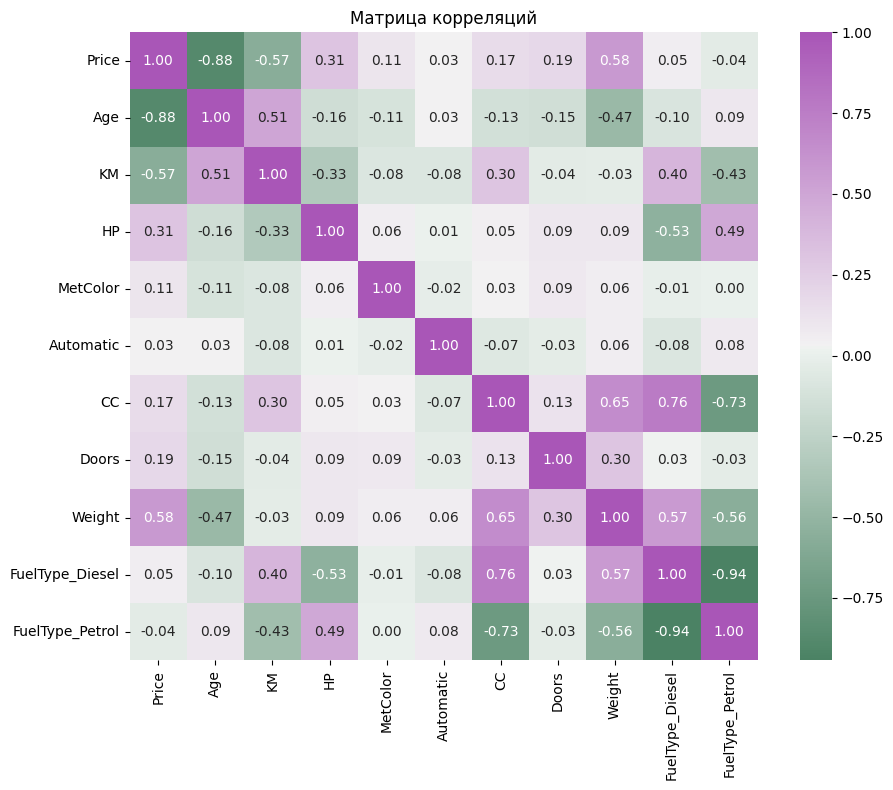

In [61]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_num.corr(), annot=True, fmt=".2f", cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True), square=True)
plt.title("Матрица корреляций")
plt.tight_layout()
plt.show()

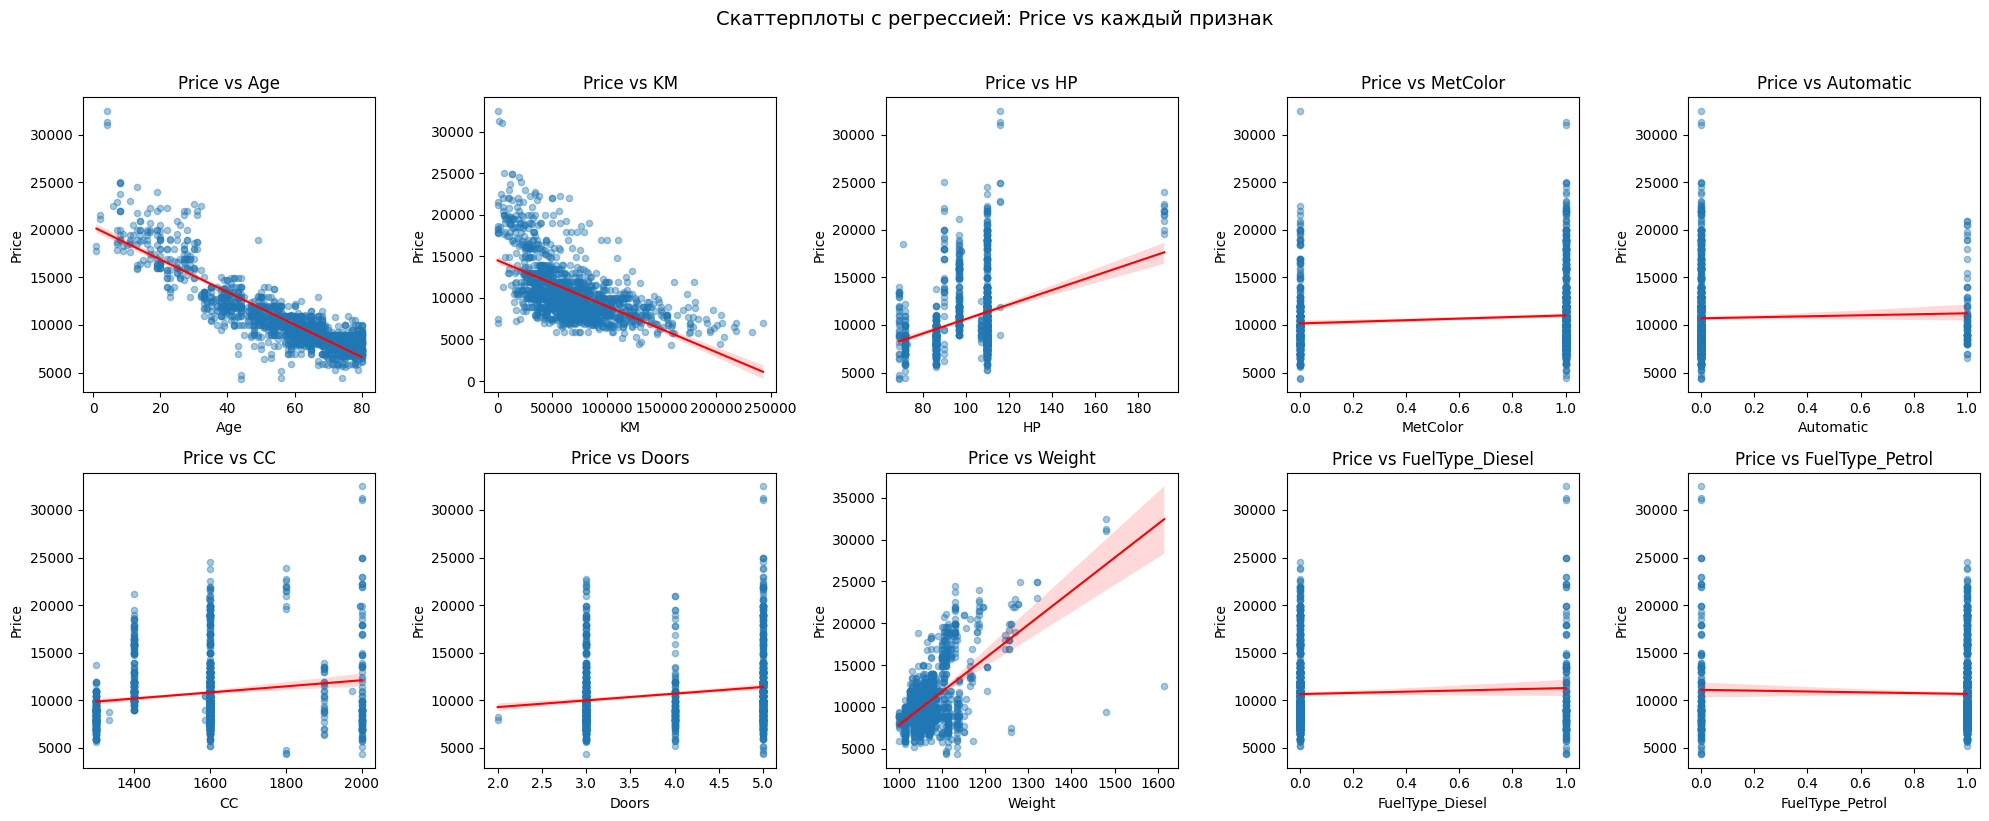

In [62]:
features = ["Age", "KM", "HP", "MetColor", "Automatic", "CC", "Doors", "Weight", "FuelType_Diesel", "FuelType_Petrol"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.regplot(data=df, x=feature, y="Price", ax=axes[i],
                scatter_kws={"alpha": 0.4, "s": 20},
                line_kws={"color": "red", "linewidth": 1.5})
    axes[i].set_title(f"Price vs {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Price")

plt.suptitle("Скаттерплоты с регрессией: Price vs каждый признак", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Удалим 2 машины, ценой выше 30000$ как выбросы. 

In [63]:
df = df[df["Price"]<30000]
df = df[df["Price"]>5000]
df = df[(df["Weight"]<1400) | (df["Price"]>20000)]

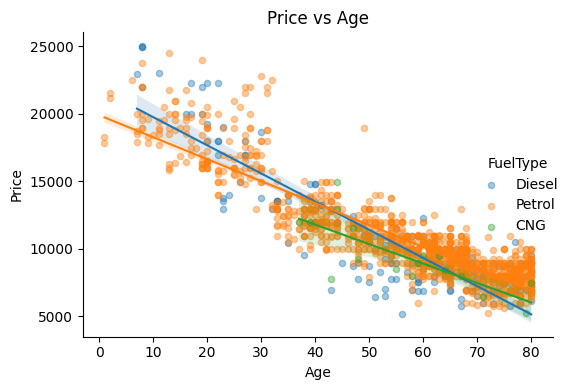

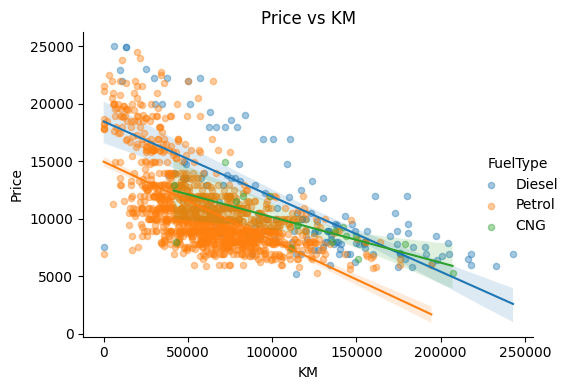

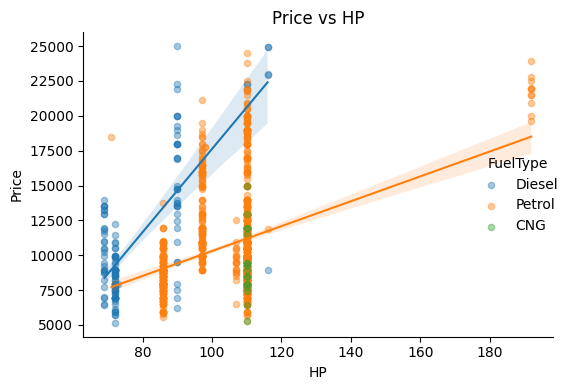

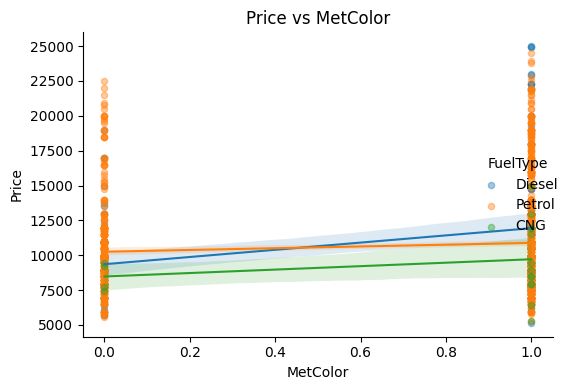

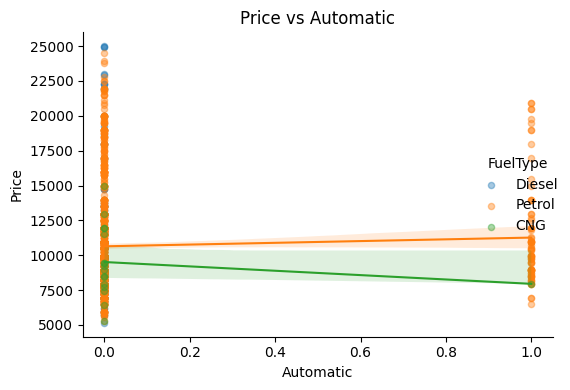

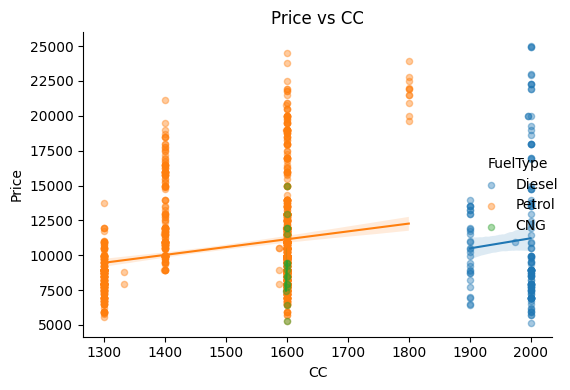

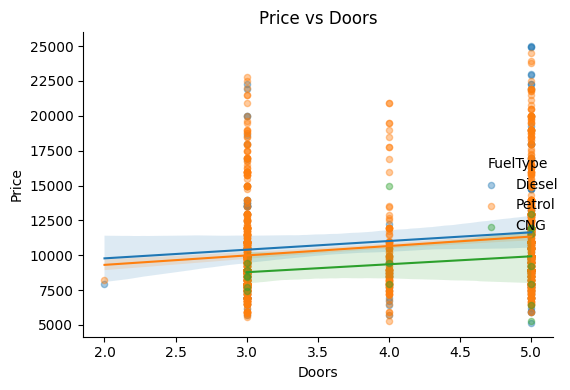

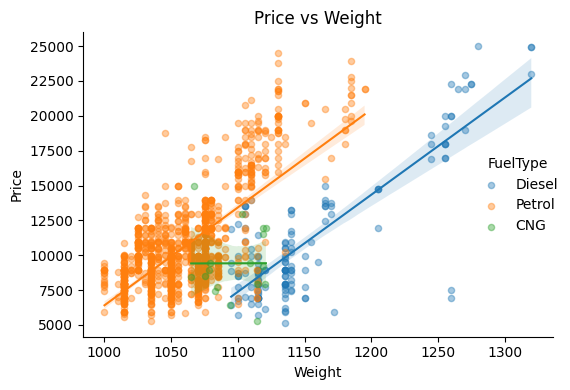

In [64]:
features = ["Age", "KM", "HP", "MetColor", "Automatic", "CC", "Doors", "Weight"]

for feature in features:
    sns.lmplot(data=df, x=feature, y="Price", hue="FuelType",
               scatter_kws={"alpha": 0.4, "s": 20},
               line_kws={"linewidth": 1.5},
               height=4, aspect=1.2)
    plt.title(f"Price vs {feature}")
    plt.tight_layout()
    plt.show()

### Удалим признаки с низкой корреляцией.

In [65]:
df = df.drop(columns=['CC', 'MetColor',  'Automatic', 'Doors', 'FuelType_Diesel', 'FuelType_Petrol', 'FuelType'])

In [66]:
y = df['Price']
X = df.drop(columns=['Price'])

In [67]:
df

,Price,Age,KM,HP,Weight
0,13500,23,46986,90,1165
1,13750,23,72937,90,1165
2,13950,24,41711,90,1165
3,14950,26,48000,90,1165
4,13750,30,38500,90,1170
...,...,...,...,...,...
1431,7500,69,20544,86,1025
1432,10845,72,19000,86,1015
1433,8500,71,17016,86,1015
1434,7250,70,16916,86,1015


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [69]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)
y_pred_train = lin_reg.predict(X_train)

In [70]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
mse_train  = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
rmse_train = np.sqrt(mse_train)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MSE_TRAIN:  {mse_train:.2f}")
print(f"RMSE_TRAIN: {rmse_train:.2f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE:  950.29
MSE:  1560823.99
RMSE: 1249.33
MSE_TRAIN:  1609636.44
RMSE_TRAIN: 1268.71
R²:   0.8582
MAPE: 9.69%


### Train и Test мало отличаются  значит модель не переобучилась.

In [71]:
params = {
    "alpha": [0.01, 0.1, 1, 10, 100],
    "fit_intercept": [True, False],
    "solver": ["auto", "svd", "cholesky", "lsqr"]
}

grid = GridSearchCV(Ridge(), param_grid=params, cv=5, scoring="r2")
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...], 'fit_intercept': [True, False], 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

In [72]:
params = {
    "alpha": [0.01, 0.1, 1, 10, 100],
    "fit_intercept": [True, False],
    "solver": ["auto", "svd", "cholesky", "lsqr"]
}

grid = GridSearchCV(Ridge(), param_grid=params, cv=5, scoring="r2")
grid.fit(X_train, y_train)


y_pred = grid.best_estimator_.predict(X_test)
y_pred_train = grid.best_estimator_.predict(X_train)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
mse_train  = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
rmse_train = np.sqrt(mse_train)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MSE_TRAIN:  {mse_train:.2f}")
print(f"RMSE_TRAIN: {rmse_train:.2f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE:  950.26
MSE:  1560839.99
RMSE: 1249.34
MSE_TRAIN:  1609637.35
RMSE_TRAIN: 1268.71
R²:   0.8582
MAPE: 9.69%


In [73]:
params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "fit_intercept": [True, False],
    "max_iter": [1000, 5000, 10000],
    "selection": ["cyclic", "random"]
}

grid = GridSearchCV(Lasso(), param_grid=params, cv=5, scoring="r2")
grid.fit(X_train, y_train)


y_pred = grid.best_estimator_.predict(X_test)
y_pred_train = grid.best_estimator_.predict(X_train)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
mse_train  = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
rmse_train = np.sqrt(mse_train)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MSE_TRAIN:  {mse_train:.2f}")
print(f"RMSE_TRAIN: {rmse_train:.2f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

C:\Users\vensv\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.829e+08, tolerance: 9.724e+06
  model = cd_fast.enet_coordinate_descent(
C:\Users\vensv\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.789e+08, tolerance: 9.876e+06
  model = cd_fast.enet_coordinate_descent(
C:\Users\vensv\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

MAE:  950.19
MSE:  1560707.25
RMSE: 1249.28
MSE_TRAIN:  1609637.39
RMSE_TRAIN: 1268.71
R²:   0.8582
MAPE: 9.68%


### Из-за того, что модель не была переобученной Разница метрик предсказаний регрессии с регуляризацией и без почти не отличаются